> **Solution version** -- this notebook contains the complete code of all exercises, executed from top to bottom, and answer elements for each observation question. The student version is available on the course webpage.


# PAC-Bayes 2 -- The classical PAC-Bayesian bounds

All the classical bounds follow from a single theorem (lecture notes, Theorem 3.1): for a convex $\Delta$, with probability $\geq 1-\delta$, for all posteriors $Q$,
$\Delta(\hat R_S(G_Q),R(G_Q))\leq \frac1m\big[\mathrm{KL}(Q\|P)+\ln\frac{\mathcal I_\Delta(m)}{\delta}\big]$.
In this notebook we implement the four bounds of Section 3, compare them, and use them on a real ensemble of voters: first with the **Gibbs posterior**,
which is the minimizer of the linear bounds, then with a **data-dependent prior** obtained by splitting the sample.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

rng = np.random.RandomState(0)

def kl_bin(q, p):
    p = min(max(p, 1e-12), 1 - 1e-12)
    t1 = q * np.log(q / p) if q > 0 else 0.0
    t2 = (1 - q) * np.log((1 - q) / (1 - p)) if q < 1 else 0.0
    return t1 + t2

def kl_inv_upper(q, eps, tol=1e-9):
    lo, hi = q, 1.0
    while hi - lo > tol:
        mid = (lo + hi) / 2
        if kl_bin(q, mid) > eps: hi = mid
        else: lo = mid
    return hi

def kl_div(q, p):
    mask = q > 0
    return np.sum(q[mask] * np.log(q[mask] / p[mask]))


## I. Implementing the bounds

With $\varepsilon=\frac{\mathrm{KL}(Q\|P)+\ln\frac{2\sqrt m}{\delta}}{m}$:

- **Seeger**: $R(G_Q)\leq \overline{\mathrm{kl}}^{-1}(\hat R_S(G_Q),\varepsilon)$;
- **McAllester**: $R(G_Q)\leq \hat R_S(G_Q)+\sqrt{\varepsilon/2}$;
- **Catoni** ($C>0$ fixed in advance): $R(G_Q)\leq \dfrac{1-\exp\big(-C\hat R_S(G_Q)-\frac{\mathrm{KL}+\ln(1/\delta)}{m}\big)}{1-e^{-C}}$;
- **PAC-Bayes-$\lambda$** (all $\lambda\in(0,2)$ simultaneously): $R(G_Q)\leq \dfrac{\hat R_S(G_Q)}{1-\lambda/2}+\dfrac{\varepsilon}{\lambda(1-\lambda/2)}$.

The first two are given below.


In [2]:
def bound_seeger(emp, KL, m, delta):
    return kl_inv_upper(emp, (KL + np.log(2 * np.sqrt(m) / delta)) / m)

def bound_mcallester(emp, KL, m, delta):
    return min(1.0, emp + np.sqrt((KL + np.log(2 * np.sqrt(m) / delta)) / (2 * m)))

print(bound_seeger(0.1, 5, 1000, 0.05), bound_mcallester(0.1, 5, 1000, 0.05))

0.15310962861403826 0.17791905124424



### Exercise 1

Implement `bound_catoni(emp, KL, m, delta, C)`, then `bound_catoni_grid(emp, KL, m, delta, grid)` which returns the best value over a grid of $C$
**with a union bound** (each value of the grid is used with confidence $\delta/|\text{grid}|$), and `bound_lambda(emp, KL, m, delta)` which uses the optimal
$\lambda^\star=2/\big(\sqrt{2m\hat R_S/(\mathrm{KL}+\ln\frac{2\sqrt m}\delta)+1}+1\big)$. Check that the value at $\lambda^\star$ is smaller than the value at 50 other values of $\lambda$ taken in $(0,2)$.


In [3]:
def bound_catoni(emp, KL, m, delta, C):
    return (1 - np.exp(-C * emp - (KL + np.log(1 / delta)) / m)) / (1 - np.exp(-C))

def bound_catoni_grid(emp, KL, m, delta, grid=np.logspace(-2, 1.5, 30)):
    return min(bound_catoni(emp, KL, m, delta / len(grid), C) for C in grid)

def bound_lambda(emp, KL, m, delta, lam=None):
    c = KL + np.log(2 * np.sqrt(m) / delta)
    if lam is None:
        lam = 2 / (np.sqrt(2 * m * emp / c + 1) + 1)
    return min(1.0, emp / (1 - lam / 2) + c / (lam * (1 - lam / 2) * m))

emp, KL, m, delta = 0.1, 5, 1000, 0.05
b_star = bound_lambda(emp, KL, m, delta)
assert all(b_star <= bound_lambda(emp, KL, m, delta, lam) + 1e-12 for lam in np.linspace(0.01, 1.99, 50))
print(f"Catoni(grid) {bound_catoni_grid(emp, KL, m, delta):.4f}  lambda* {b_star:.4f}  Seeger {bound_seeger(emp, KL, m, delta):.4f}")

Catoni(grid) 0.1513  lambda* 0.1629  Seeger 0.1531



Let us now compare the four bounds when the sample size grows, for an empirical Gibbs risk of $0.1$ and of $0$.


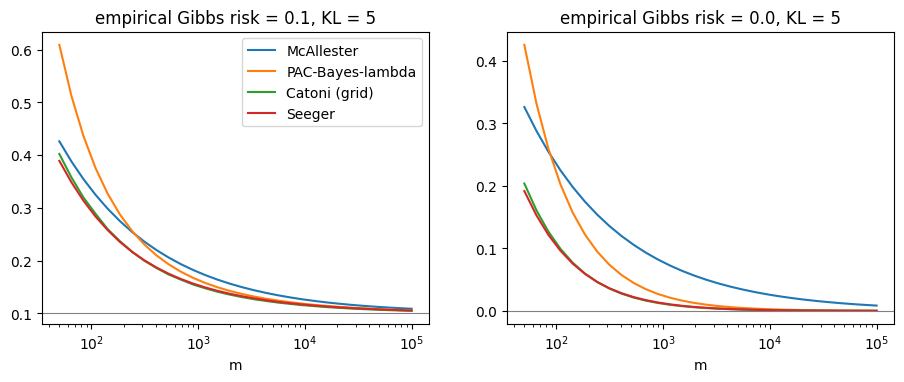

In [4]:
ms = np.unique(np.logspace(1.7, 5, 30).astype(int))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, emp in zip(axes, [0.1, 0.0]):
    for f, lab in [(bound_mcallester, "McAllester"), (bound_lambda, "PAC-Bayes-lambda"),
                   (bound_catoni_grid, "Catoni (grid)"), (bound_seeger, "Seeger")]:
        ax.plot(ms, [f(emp, 5, m, 0.05) for m in ms], label=lab)
    ax.axhline(emp, color="grey", lw=0.8)
    ax.set_xscale("log"); ax.set_xlabel("m"); ax.set_title(f"empirical Gibbs risk = {emp}, KL = 5")
axes[0].legend(); plt.show()

$$ $$

**Question 1:** Rank the bounds from the tightest to the loosest. When the empirical risk is $0$, how fast do McAllester's bound and Seeger's bound decrease with $m$? Explain with the refined Pinsker inequality.

$$ $$

*Answer elements.* Seeger and Catoni (optimized on a grid of $C$) are the tightest and almost indistinguishable (Catoni can even be marginally smaller, since it does not pay the $\ln 2\sqrt m$ term, at the price of the union bound over the grid); PAC-Bayes-$\lambda$ is slightly looser, and McAllester is the loosest. With a zero empirical risk, McAllester decreases as $1/\sqrt m$ while Seeger gives $1-e^{-\varepsilon}\approx\varepsilon$, i.e. $1/m$: for small $\hat q$, $\mathrm{kl}(\hat q\|p)\geq (p-\hat q)^2/(2p)$ gives $p\leq \hat q+\sqrt{2\hat q\varepsilon}+2\varepsilon$, a fast rate when $\hat q\approx 0$.


## II. The Gibbs posterior on a set of voters

We now use a finite set of voters: **shallow decision trees learned on bootstrap samples of a separate "prior" set**. This matters: the prior (uniform over these trees) must not depend on the sample on which we evaluate the bound.
We split the data in three parts: `S_prior` (to build the voters), `S` (to compute the bound, $m$ examples) and a test set.


In [5]:
X, y = load_breast_cancer(return_X_y=True)
y = 2 * y - 1
X_prior, X_rest, y_prior, y_rest = train_test_split(X, y, train_size=0.3, random_state=1)
X_S, X_te, y_S, y_te = train_test_split(X_rest, y_rest, test_size=0.4, random_state=1)

n_voters = 200
voters = []
for t in range(n_voters):
    idx = rng.randint(0, len(y_prior), len(y_prior))
    voters.append(DecisionTreeClassifier(max_depth=rng.randint(1, 4), max_features="sqrt",
                                         random_state=t).fit(X_prior[idx], y_prior[idx]))
V_S = np.array([v.predict(X_S) for v in voters])
V_te = np.array([v.predict(X_te) for v in voters])
emp = (V_S != y_S).mean(1); test = (V_te != y_te).mean(1)
m, delta = len(y_S), 0.05
P = np.ones(n_voters) / n_voters
print(f"m = {m}, empirical risks of the voters in [{emp.min():.3f}, {emp.max():.3f}]")

m = 239, empirical risks of the voters in [0.063, 0.356]



The Gibbs posterior is $Q_\lambda(h)\propto P(h)\,e^{-\lambda m \hat R_S(h)}$. For small $\lambda$ it is close to the prior, for large $\lambda$ it concentrates on the best voters.


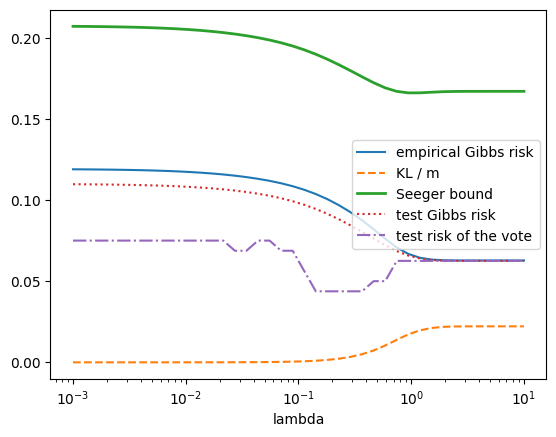

best lambda = 0.943: bound 0.166, test Gibbs 0.066, test vote 0.062


In [6]:
def gibbs_posterior(P, emp, lam, m):
    logw = np.log(P) - lam * m * emp
    w = np.exp(logw - logw.max())
    return w / w.sum()

lams = np.logspace(-3, 1, 40)
res = []
for lam in lams:
    Q = gibbs_posterior(P, emp, lam, m)
    KL = kl_div(Q, P)
    res.append((Q @ emp, KL, bound_seeger(Q @ emp, KL, m, delta), Q @ test,
                np.mean(np.where(Q @ V_te >= 0, 1, -1) != y_te)))
res = np.array(res)
plt.plot(lams, res[:, 0], label="empirical Gibbs risk")
plt.plot(lams, res[:, 1] / m, "--", label="KL / m")
plt.plot(lams, res[:, 2], lw=2, label="Seeger bound")
plt.plot(lams, res[:, 3], ":", label="test Gibbs risk")
plt.plot(lams, res[:, 4], "-.", label="test risk of the vote")
plt.xscale("log"); plt.xlabel("lambda"); plt.legend(); plt.show()
i = np.argmin(res[:, 2])
print(f"best lambda = {lams[i]:.3f}: bound {res[i, 2]:.3f}, test Gibbs {res[i, 3]:.3f}, test vote {res[i, 4]:.3f}")

$$ $$

**Question 2:** Describe the evolution of the empirical Gibbs risk and of the KL with $\lambda$. Is the bound valid (above the test Gibbs risk) for all $\lambda$? Can we report the minimum of the curve as a certificate?

$$ $$

*Answer elements.* The empirical Gibbs risk decreases with $\lambda$ while the KL increases (up to $\ln 200$ minus the log-number of minimizers): the bound is minimized at an intermediate temperature. It stays above the test Gibbs risk. Reporting the minimum over the 40 values of $\lambda$ is legitimate here because Seeger's bound holds *for all posteriors simultaneously*: $\lambda$ only indexes a family of posteriors, no union bound is needed. (A union bound would be required for a parameter of the bound itself, like $C$ in Catoni's bound.)

$$ $$

**Question 3:** Compare the test risk of the vote with the test Gibbs risk. Which $\lambda$ would you choose if you care about the vote?

$$ $$

*Answer elements.* The vote is better than the Gibbs classifier, and its best performance is usually obtained for smaller $\lambda$ (more spread-out posterior, more diversity) than the minimizer of the Gibbs bound. The first-order view (bounding the Gibbs risk) is not aligned with the performance of the vote; notebooks 3 and 4 address this with second-order bounds.


### Exercise 2

The Gibbs posterior minimizes $\hat R_S(G_Q)+\frac{\mathrm{KL}(Q\|P)}{\lambda m}$. Check it numerically for $\lambda=0.5$: draw 2000 random posteriors
(Dirichlet with parameter $0.2$) and check that none of them achieves a smaller value of this objective than $Q_\lambda$. Also check that the minimal value is
$-\frac{1}{\lambda m}\ln \mathbb E_{h\sim P} e^{-\lambda m\hat R_S(h)}$.


In [7]:
# Model: the same kind of check for the "entropy-regularized" objective  <Q, c> - H(Q)
c = rng.randn(10)
obj = lambda Q: Q @ c + np.sum(Q * np.log(np.maximum(Q, 1e-300)))
Qstar = np.exp(-c) / np.exp(-c).sum()
print(obj(Qstar), -np.log(np.exp(-c).sum()))
print(all(obj(rng.dirichlet(0.5 * np.ones(10))) >= obj(Qstar) for _ in range(1000)))

-3.3662669636981972 -3.3662669636981972
True


In [8]:
lam = 0.5
obj = lambda Q: Q @ emp + kl_div(Q, P) / (lam * m)
Ql = gibbs_posterior(P, emp, lam, m)
best_random = min(obj(rng.dirichlet(0.2 * np.ones(n_voters))) for _ in range(2000))
print(f"objective at Q_lambda: {obj(Ql):.5f}   best random posterior: {best_random:.5f}")
assert obj(Ql) <= best_random
a = -lam * m * emp
closed = -(np.log(np.mean(np.exp(a - a.max()))) + a.max()) / (lam * m)
np.testing.assert_allclose(obj(Ql), closed, rtol=1e-8)

objective at Q_lambda: 0.09648   best random posterior: 0.11956



## III. Using all the data: prior built on part of the sample

In part II we "sacrificed" 30% of the data to build the voters. A natural question is the size of the split: more data for the prior gives better voters,
but a smaller $m$ in the bound. Let us study it.


In [9]:
def certificate(frac_prior, seed=0, n_voters=200):
    r = np.random.RandomState(seed)
    Xp, Xr, yp, yr = train_test_split(X, y, train_size=frac_prior, random_state=seed)
    XS, Xt, yS, yt = train_test_split(Xr, yr, test_size=0.3, random_state=seed)
    vs = []
    for t in range(n_voters):
        idx = r.randint(0, len(yp), len(yp))
        vs.append(DecisionTreeClassifier(max_depth=r.randint(1, 4), max_features="sqrt",
                                         random_state=t).fit(Xp[idx], yp[idx]))
    e = np.array([(v.predict(XS) != yS).mean() for v in vs])
    te = np.array([(v.predict(Xt) != yt).mean() for v in vs])
    mm = len(yS); Pu = np.ones(n_voters) / n_voters
    best = (1.0, None)
    for lam in np.logspace(-3, 1, 30):
        Q = gibbs_posterior(Pu, e, lam, mm)
        b = bound_seeger(Q @ e, kl_div(Q, Pu), mm, 0.05)
        if b < best[0]:
            best = (b, Q @ te)
    return mm, best

for frac in [0.05, 0.1, 0.3, 0.5, 0.7, 0.85]:
    out = [certificate(frac, seed) for seed in range(5)]      # average over 5 random splits
    mm = out[0][0]
    b = np.mean([o[1][0] for o in out]); t = np.mean([o[1][1] for o in out])
    print(f"prior fraction {frac:.2f}: m = {mm:3d}, best Seeger bound {b:.3f}, test Gibbs risk {t:.3f}  (mean of 5 splits)")

prior fraction 0.05: m = 378, best Seeger bound 0.142, test Gibbs risk 0.080  (mean of 5 splits)


prior fraction 0.10: m = 359, best Seeger bound 0.135, test Gibbs risk 0.077  (mean of 5 splits)


prior fraction 0.30: m = 279, best Seeger bound 0.136, test Gibbs risk 0.067  (mean of 5 splits)


prior fraction 0.50: m = 199, best Seeger bound 0.142, test Gibbs risk 0.087  (mean of 5 splits)


prior fraction 0.70: m = 119, best Seeger bound 0.180, test Gibbs risk 0.059  (mean of 5 splits)


prior fraction 0.85: m =  60, best Seeger bound 0.225, test Gibbs risk 0.059  (mean of 5 splits)


$$ $$

**Question 4:** Which split gives the best certificate? Explain the trade-off. How could the bagging construction avoid "wasting" data (see Section 7.2 of the lecture notes)?

$$ $$

*Answer elements.* With a small prior set the voters are weak (large empirical risk), with a large prior set $m$ is small and the complexity term $\ln(2\sqrt m/\delta)/m$ blows up; an intermediate split (here around 10-30% of the data for the prior) is best, and the certificate degrades quickly when fewer than ~150 examples are left for the bound. Note that the test Gibbs risk is noisy: the voters are random and the test sets small. With bagging, each voter is trained on a bootstrap sample and evaluated on its own out-of-bag examples: every example is used both to build some voters and to evaluate others, and no data is sacrificed (split construction of Thiemann et al., 2017, notebook 4).


### Exercise 3 (Master level)

Catoni's bound with a grid of $C$ requires a union bound, while Seeger's bound does not. On the setting of part II (breast cancer, 200 voters),
compute for each $\lambda$ of the grid `lams` the four bounds (McAllester, Catoni with the grid of $C$ and union bound, PAC-Bayes-$\lambda$ at $\lambda^\star$, Seeger)
applied to $Q_\lambda$, plot them together with the test Gibbs risk, and report the best certificate of each bound. Then do the same on the `digits` dataset (classes $<5$ vs $\geq 5$). Comment.


In [10]:
# Model on part II data: McAllester and Seeger only
bm, bs = [], []
for lam in lams:
    Q = gibbs_posterior(P, emp, lam, m); KL = kl_div(Q, P)
    bm.append(bound_mcallester(Q @ emp, KL, m, delta)); bs.append(bound_seeger(Q @ emp, KL, m, delta))
print(f"best McAllester {min(bm):.3f}, best Seeger {min(bs):.3f}")

best McAllester 0.213, best Seeger 0.166


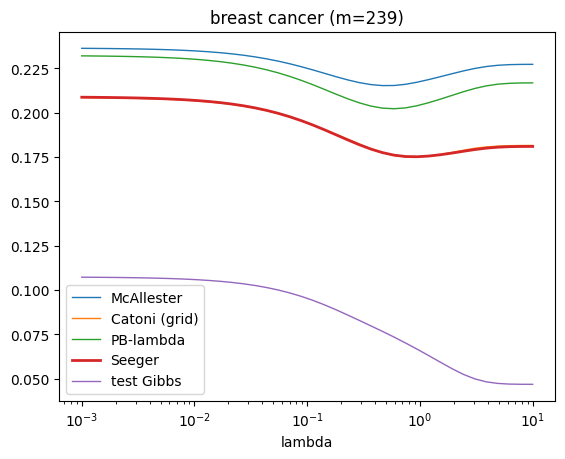

{'McAllester': np.float64(0.215), 'Catoni (grid)': np.float64(0.175), 'PB-lambda': np.float64(0.202), 'Seeger': np.float64(0.175)}


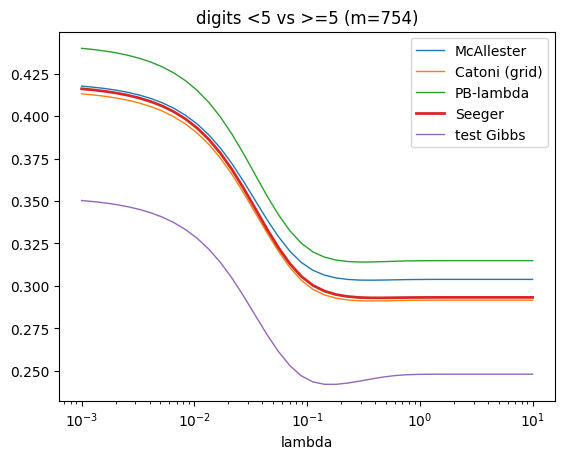

{'McAllester': np.float64(0.303), 'Catoni (grid)': np.float64(0.291), 'PB-lambda': np.float64(0.314), 'Seeger': np.float64(0.293)}


In [11]:
def study(X, y, name, n_voters=200, seed=1):
    r = np.random.RandomState(seed)
    Xp, Xr, yp, yr = train_test_split(X, y, train_size=0.3, random_state=seed)
    XS, Xt, yS, yt = train_test_split(Xr, yr, test_size=0.4, random_state=seed)
    vs = []
    for t in range(n_voters):
        idx = r.randint(0, len(yp), len(yp))
        vs.append(DecisionTreeClassifier(max_depth=r.randint(1, 4), max_features="sqrt",
                                         random_state=t).fit(Xp[idx], yp[idx]))
    e = np.array([(v.predict(XS) != yS).mean() for v in vs])
    te = np.array([(v.predict(Xt) != yt).mean() for v in vs])
    mm = len(yS); Pu = np.ones(n_voters) / n_voters
    out = {k: [] for k in ["McAllester", "Catoni (grid)", "PB-lambda", "Seeger", "test Gibbs"]}
    for lam in lams:
        Q = gibbs_posterior(Pu, e, lam, mm); KL = kl_div(Q, Pu)
        out["McAllester"].append(bound_mcallester(Q @ e, KL, mm, 0.05))
        out["Catoni (grid)"].append(bound_catoni_grid(Q @ e, KL, mm, 0.05))
        out["PB-lambda"].append(bound_lambda(Q @ e, KL, mm, 0.05))
        out["Seeger"].append(bound_seeger(Q @ e, KL, mm, 0.05))
        out["test Gibbs"].append(Q @ te)
    for k, v in out.items():
        plt.plot(lams, v, label=k, lw=2 if k == "Seeger" else 1)
    plt.xscale("log"); plt.xlabel("lambda"); plt.title(f"{name} (m={mm})"); plt.legend(); plt.show()
    print({k: round(min(v), 3) for k, v in out.items() if k != "test Gibbs"})

study(X, y, "breast cancer")
Xd, yd = load_digits(return_X_y=True)
study(Xd, np.where(yd >= 5, 1, -1), "digits <5 vs >=5")

*Answer elements.* On both datasets the ranking of part I is preserved: Seeger and Catoni (grid) give the best certificates (within a few thousandths of each other), PAC-Bayes-$\lambda$ is a bit looser and McAllester is the loosest. On `digits` the voters are weaker (shallow trees on 64 pixels), the certificates are larger but still non-vacuous. The union bound over the grid of $C$ costs only $\ln 30\approx 3.4$ nats, which is visible but small.


## Conclusion

The kl form (Seeger) should be used to compute the final certificate; linear bounds (Catoni, PAC-Bayes-$\lambda$) are useful to *derive* posteriors,
since their minimizer is the Gibbs posterior. The prior must be independent of the evaluation sample, which costs data unless we use a split construction such as bagging.
